In [1]:
import os 
import torch
# torch.autograd.set_detect_anomaly(True)


# CLASSES_FILE = r'data\archive\class_names.txt'
CLASSES_FILE = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Train\high\Classes\class_names.txt'
BATCH_SIZE=8 
IMG_SIZE=(640, 640)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
from modules.data_obj import LoLiStreetDataset_Curated 
from torch.utils.data import DataLoader
import torchvision.transforms as T
import pandas as pd 


# train_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\Train'
# val_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\Val'

train_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\Train'
val_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\Val'

# train_GT_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\YOLO Annotations\Train'
# val_GT_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\YOLO Annotations\Val'

train_GT_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Train'
val_GT_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Val'

# train_curated_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\curated_dataset.csv'
# val_curated_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\val_curated_dataset.csv'

train_curated_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\curated_dataset.csv'
val_curated_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\val_curated_dataset.csv'

# Define paths for the new split files
# val_split_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\val_split.csv'
# test_split_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\test_split.csv'

val_split_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\val_split.csv'
test_split_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\test_split.csv'

# 1. Load the original 200-row CSV
df_val_full = pd.read_csv(val_curated_pth)

# 2. Shuffle the rows 
# Using random_state=42 ensures you get the exact same split every time you run this script
df_shuffled = df_val_full.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Split down the middle (100 and 100)
df_val_final = df_shuffled.iloc[:100]
df_test_final = df_shuffled.iloc[100:]

# 4. Save the new splits
df_val_final.to_csv(val_split_pth, index=False)
df_test_final.to_csv(test_split_pth, index=False)

print(f"Created Val Split: {len(df_val_final)} scenes")
print(f"Created Test Split: {len(df_test_final)} scenes")

try:
    data_transform = T.ToTensor() 

    print("Initializing Train Dataset...")
    train_dataset = LoLiStreetDataset_Curated(
        csv_path=train_curated_pth,
        high_dir=os.path.join(train_root, 'high'), 
        low_dir=os.path.join(train_root, 'low'), 
        high_gt_dir=os.path.join(train_GT_root, 'high/Labels'),
        low_gt_dir=os.path.join(train_GT_root, 'low/Labels')
    )
    
    print("Initializing Val Dataset...")
    val_dataset = LoLiStreetDataset_Curated(
        csv_path=val_split_pth,
        high_dir=os.path.join(val_root, 'high'), 
        low_dir=os.path.join(val_root, 'low'), 
        high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
        low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels')
    )

    print("Initializing Val Dataset...")
    test_dataset = LoLiStreetDataset_Curated(
        csv_path=test_split_pth,
        high_dir=os.path.join(val_root, 'high'), 
        low_dir=os.path.join(val_root, 'low'), 
        high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
        low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels')
    )
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)

    print(f"\nSUCCESS: Datasets created. Train size: {len(train_dataset)}")

except Exception as e:
    print(f"\n[ERROR] Failed to initialize datasets: {e}")

Created Val Split: 100 scenes
Created Test Split: 100 scenes
Initializing Train Dataset...
Parsing CSV... Found 1700 curated scenes.
Dataset Built! Expanded to 5100 total image-label pairs.
Initializing Val Dataset...
Parsing CSV... Found 100 curated scenes.
Dataset Built! Expanded to 300 total image-label pairs.
Initializing Val Dataset...
Parsing CSV... Found 100 curated scenes.
Dataset Built! Expanded to 300 total image-label pairs.

SUCCESS: Datasets created. Train size: 5100


In [3]:

def run_sanity_check(dataset, scenes_to_check=2):
    print(f"Total Dataset Size: {len(dataset)} pairs")
    print("=" * 60)
    
    # We check scenes_to_check * 3 because there are 3 illumination variants per scene
    items_to_check = min(scenes_to_check * 3, len(dataset))
    
    for i in range(items_to_check):
        # 1. Check the raw file paths we stored in the lists
        low_img_path = dataset.low_images[i]
        high_img_path = dataset.high_images[i]
        label_file_path = dataset.labels_files[i]
        
        # 2. Pull the actual item to make sure __getitem__ runs smoothly
        data = dataset[i]
        num_bboxes = data['bboxes'].shape[0]
        
        print(f"Dataset Index [{i}]:")
        print(f"  Low Input:  {os.path.basename(low_img_path)}")
        print(f"  High Target:{os.path.basename(high_img_path)}")
        print(f"  GT Label:   {os.path.basename(label_file_path)} ---> ({num_bboxes} boxes loaded)")
        
        # Print a divider after every 3rd image (end of a scene triplet)
        if (i + 1) % 3 == 0:
            print("-" * 60)

# Run it!
# run_sanity_check(train_dataset, scenes_to_check=2)
# run_sanity_check(val_dataset, scenes_to_check=2)
# run_sanity_check(test_dataset, scenes_to_check=2)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_dataset_sample(dataset, index=0):
    # 1. Fetch the data dictionary from the dataset
    data = dataset[index]
    
    # 2. Extract tensors
    img_low_tensor = data['images_low']
    img_high_tensor = data['images_high']
    bboxes = data['bboxes']
    classes = data['cls']
    im_id = data['im_id']
    
    # 3. Convert tensors [C, H, W] back to numpy arrays [H, W, C] for matplotlib
    # Since they were divided by 255.0, they are in the [0, 1] range, which plt.imshow handles natively
    img_low_np = img_low_tensor.permute(1, 2, 0).numpy()
    img_high_np = img_high_tensor.permute(1, 2, 0).numpy()
    
    # Get the actual dimensions of the padded tensor (e.g., 640x640)
    tensor_h, tensor_w = img_low_np.shape[:2]
    
    # 4. Setup the plot
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f"Sanity Check: Adjusted Bboxes on Padded Tensors | Image ID: {im_id}", fontsize=16)
    
    for ax, img, title in zip(axs, [img_low_np, img_high_np], ["Low Input", "High Target (Ground Truth)"]):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
        
        # 5. Draw the bounding boxes
        for i in range(len(bboxes)):
            # YOLO format is normalized [x_center, y_center, width, height]
            x_c, y_c, w, h = bboxes[i].numpy()
            cls_id = classes[i].item()
            
            # Convert normalized relative coordinates back to absolute pixel coordinates
            abs_x_c = x_c * tensor_w
            abs_y_c = y_c * tensor_h
            abs_w = w * tensor_w
            abs_h = h * tensor_h
            
            # Matplotlib Rectangle needs the top-left corner
            top_left_x = abs_x_c - (abs_w / 2)
            top_left_y = abs_y_c - (abs_h / 2)
            
            # Create the rectangle patch
            rect = patches.Rectangle(
                (top_left_x, top_left_y), abs_w, abs_h, 
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            
            # Optional: Add class label text
            ax.text(top_left_x, top_left_y - 5, f'Class {cls_id}', 
                    color='black', backgroundcolor='lime', fontsize=9, weight='bold')
            
    plt.tight_layout()
    plt.show()

# # Run it on a few different samples!
# visualize_dataset_sample(test_dataset, index=0)  # Should be the 'dense' version
# visualize_dataset_sample(test_dataset, index=1)  # Should be the 'moderate' version
# visualize_dataset_sample(test_dataset, index=2)  # Should be the 'light' version

In [5]:
from models.illuminet import IllumiNet_b5_ARB, IllumiNet_b5_ARB_Scale


# baseline = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=False)
# backARB = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=False)
# decARB = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)
# bothARB = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=True)

355


In [6]:
from training.train import ModelTrainer
from losses.yolo_loss import DetectionLoss
from losses.llie_loss import mean_abs_error


baseline_scale = IllumiNet_b5_ARB_Scale(back_use_arb=False, dec_arb=False)
def_det_loss_fn = DetectionLoss(model=baseline_scale, device=DEVICE)

baseline_trainer = ModelTrainer(
    model=baseline_scale,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=60,
    det_loss_fn=def_det_loss_fn,
    enhance_loss_fn=mean_abs_error,
    experiment_name='baseline_SS',
    # device=DEVICE
)

training_hist = baseline_trainer.fit()
df_hist = pd.DataFrame(training_hist)
df_hist.to_csv('training_hist_baseline_SS.csv', index=False)

IllumiNet with Scaler Initialized
Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Starting training on cuda for 60 epochs...


Epoch 0/60:   0%|          | 0/638 [00:00<?, ?it/s]c:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\losses\yolo_loss.py:430: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))
c:\Users\Sistem Cerdas Five\Desktop\vian\afre\venv\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Validation:   0%|          | 0/38 [00:00<?, ?it/s]c:\Users\Sistem Cerdas Five\Desktop\vian\afre\venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWar


🏆 **mAP Improved!** (0.0193 > -inf) at Epoch 0. Saving model.

--- Epoch 0 Summary (157.59s) ---
Train Loss: 48.9392 | Val Loss: 36.0293
Enhancement: PSNR=21.62 | SSIM=0.789
Detection: mAP@0.5=0.019
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [01:36<00:00,  6.60it/s, TLoss=12.0666, DLoss=20.0865, ELoss=0.0367, LR_BB=2.80e-05, LR_Det=2.80e-05, LR_Dec=2.80e-04]



🏆 **mAP Improved!** (0.1315 > 0.0193) at Epoch 1. Saving model.

--- Epoch 1 Summary (96.63s) ---
Train Loss: 28.1591 | Val Loss: 22.5333
Enhancement: PSNR=23.94 | SSIM=0.877
Detection: mAP@0.5=0.132
-------------------------------------------



...


No improvement in mAP (0.2347 ≤ 0.2836). Skipping save.

--- Epoch 57 Summary (92.60s) ---
Train Loss: 5.3630 | Val Loss: 14.1932
Enhancement: PSNR=27.66 | SSIM=0.931
Detection: mAP@0.5=0.235
-------------------------------------------



Epoch 58/60: 100%|██████████| 638/638 [01:32<00:00,  6.88it/s, TLoss=2.8130, DLoss=4.6799, ELoss=0.0126, LR_BB=8.47e-08, LR_Det=8.47e-08, LR_Dec=8.47e-07]



No improvement in mAP (0.2322 ≤ 0.2836). Skipping save.

--- Epoch 58 Summary (92.70s) ---
Train Loss: 5.3641 | Val Loss: 14.1308
Enhancement: PSNR=28.22 | SSIM=0.931
Detection: mAP@0.5=0.232
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [01:32<00:00,  6.87it/s, TLoss=3.0125, DLoss=5.0110, ELoss=0.0147, LR_BB=4.00e-10, LR_Det=4.00e-10, LR_Dec=4.00e-09]



No improvement in mAP (0.2321 ≤ 0.2836). Skipping save.

--- Epoch 59 Summary (92.85s) ---
Train Loss: 5.3634 | Val Loss: 14.1753
Enhancement: PSNR=28.08 | SSIM=0.931
Detection: mAP@0.5=0.232
-------------------------------------------

Training Complete. Final model saved to final_baseline_SS_epoch60.pt


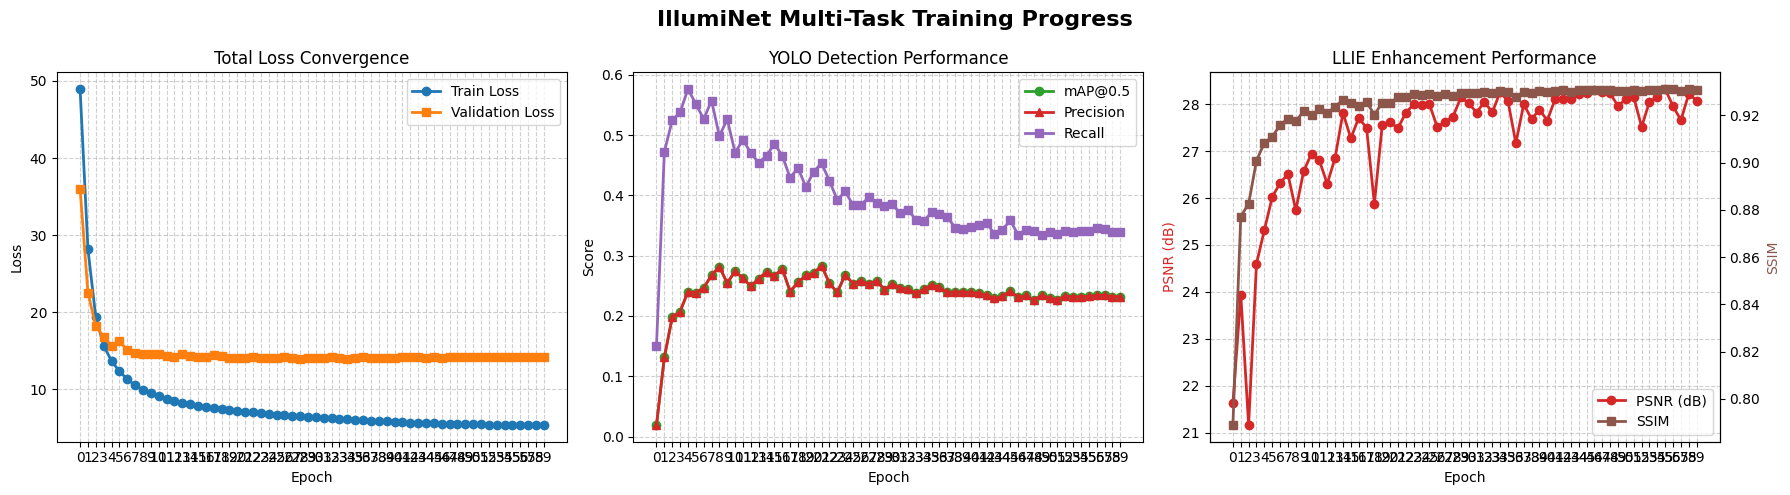

In [7]:
def visualize_train_plots(training_hist): # Extract data
    epochs = [h['epoch'] for h in training_hist]
    train_loss = [h['train_loss_total'] for h in training_hist]
    val_loss = [h['val_loss_total'] for h in training_hist]

    val_map50 = [h['val_mAP50'] for h in training_hist]
    val_prec_prox = [h['val_prec_prox'] for h in training_hist]
    val_recall = [h['val_recall'] for h in training_hist]

    val_psnr = [h['val_psnr'] for h in training_hist]
    val_ssim = [h['val_ssim'] for h in training_hist]

    # Set up the figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('IllumiNet Multi-Task Training Progress', fontsize=16, fontweight='bold')

    # --- Plot 1: Total Loss ---
    axs[0].plot(epochs, train_loss, label='Train Loss', color='tab:blue', marker='o', linewidth=2)
    axs[0].plot(epochs, val_loss, label='Validation Loss', color='tab:orange', marker='s', linewidth=2)
    axs[0].set_title('Total Loss Convergence')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_xticks(epochs)
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].legend()

    # --- Plot 2: Detection Metrics ---
    axs[1].plot(epochs, val_map50, label='mAP@0.5', color='tab:green', marker='o', linewidth=2)
    axs[1].plot(epochs, val_prec_prox, label='Precision', color='tab:red', marker='^', linewidth=2) # Added Precision
    axs[1].plot(epochs, val_recall, label='Recall', color='tab:purple', marker='s', linewidth=2)
    axs[1].set_title('YOLO Detection Performance')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Score')
    axs[1].set_xticks(epochs)
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].legend()

    # --- Plot 3: Enhancement Metrics (Dual Axis) ---
    ax3 = axs[2]
    ax3_twin = ax3.twinx()

    line1 = ax3.plot(epochs, val_psnr, label='PSNR (dB)', color='tab:red', marker='o', linewidth=2)
    line2 = ax3_twin.plot(epochs, val_ssim, label='SSIM', color='tab:brown', marker='s', linewidth=2)

    ax3.set_title('LLIE Enhancement Performance')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('PSNR (dB)', color='tab:red')
    ax3_twin.set_ylabel('SSIM', color='tab:brown')
    ax3.set_xticks(epochs)
    ax3.grid(True, linestyle='--', alpha=0.6)

    # Combine legends for the dual axis
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='lower right')

    plt.tight_layout()
    plt.show()
    

visualize_train_plots(training_hist=training_hist)

In [8]:
from training.train import ModelTrainer
from losses.yolo_loss import DetectionLoss
from losses.llie_loss import mean_abs_error

def visualize_train_plots(training_hist): # Extract data
    epochs = [h['epoch'] for h in training_hist]
    train_loss = [h['train_loss_total'] for h in training_hist]
    val_loss = [h['val_loss_total'] for h in training_hist]

    val_map50 = [h['val_mAP50'] for h in training_hist]
    val_prec_prox = [h['val_prec_prox'] for h in training_hist]
    val_recall = [h['val_recall'] for h in training_hist]

    val_psnr = [h['val_psnr'] for h in training_hist]
    val_ssim = [h['val_ssim'] for h in training_hist]

    # Set up the figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('IllumiNet Multi-Task Training Progress', fontsize=16, fontweight='bold')

    # --- Plot 1: Total Loss ---
    axs[0].plot(epochs, train_loss, label='Train Loss', color='tab:blue', marker='o', linewidth=2)
    axs[0].plot(epochs, val_loss, label='Validation Loss', color='tab:orange', marker='s', linewidth=2)
    axs[0].set_title('Total Loss Convergence')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_xticks(epochs)
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].legend()

    # --- Plot 2: Detection Metrics ---
    axs[1].plot(epochs, val_map50, label='mAP@0.5', color='tab:green', marker='o', linewidth=2)
    axs[1].plot(epochs, val_prec_prox, label='Precision', color='tab:red', marker='^', linewidth=2) # Added Precision
    axs[1].plot(epochs, val_recall, label='Recall', color='tab:purple', marker='s', linewidth=2)
    axs[1].set_title('YOLO Detection Performance')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Score')
    axs[1].set_xticks(epochs)
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].legend()

    # --- Plot 3: Enhancement Metrics (Dual Axis) ---
    ax3 = axs[2]
    ax3_twin = ax3.twinx()

    line1 = ax3.plot(epochs, val_psnr, label='PSNR (dB)', color='tab:red', marker='o', linewidth=2)
    line2 = ax3_twin.plot(epochs, val_ssim, label='SSIM', color='tab:brown', marker='s', linewidth=2)

    ax3.set_title('LLIE Enhancement Performance')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('PSNR (dB)', color='tab:red')
    ax3_twin.set_ylabel('SSIM', color='tab:brown')
    ax3.set_xticks(epochs)
    ax3.grid(True, linestyle='--', alpha=0.6)

    # Combine legends for the dual axis
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='lower right')

    plt.tight_layout()
    plt.show()
    


IllumiNet with Scaler Initialized
Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Starting training on cuda for 60 epochs...


Epoch 0/60:   0%|          | 0/638 [00:00<?, ?it/s]c:\Users\Sistem Cerdas Five\Desktop\vian\afre\venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch 0/60: 100%|██████████| 638/638 [01:49<00:00,  5.81it/s, TLoss=15.3240, DLoss=25.5087, ELoss=0.0468, LR_BB=1.04e-05, LR_Det=1.04e-05, LR_Dec=1.04e-04] 



🏆 **mAP Improved!** (0.0377 > -inf) at Epoch 0. Saving model.

--- Epoch 0 Summary (109.80s) ---
Train Loss: 45.8938 | Val Loss: 32.4266
Enhancement: PSNR=21.76 | SSIM=0.803
Detection: mAP@0.5=0.038
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [01:49<00:00,  5.82it/s, TLoss=9.9649, DLoss=16.5824, ELoss=0.0386, LR_BB=2.80e-05, LR_Det=2.80e-05, LR_Dec=2.80e-04] 



🏆 **mAP Improved!** (0.1299 > 0.0377) at Epoch 1. Saving model.

--- Epoch 1 Summary (109.58s) ---
Train Loss: 25.5987 | Val Loss: 21.3357
Enhancement: PSNR=23.35 | SSIM=0.878
Detection: mAP@0.5=0.130
-------------------------------------------



...


No improvement in mAP (0.2484 ≤ 0.2891). Skipping save.

--- Epoch 57 Summary (111.58s) ---
Train Loss: 5.1210 | Val Loss: 13.6307
Enhancement: PSNR=29.61 | SSIM=0.934
Detection: mAP@0.5=0.248
-------------------------------------------



Epoch 58/60: 100%|██████████| 638/638 [01:52<00:00,  5.68it/s, TLoss=2.7030, DLoss=4.4939, ELoss=0.0167, LR_BB=8.47e-08, LR_Det=8.47e-08, LR_Dec=8.47e-07]



No improvement in mAP (0.2510 ≤ 0.2891). Skipping save.

--- Epoch 58 Summary (112.24s) ---
Train Loss: 5.1153 | Val Loss: 13.6569
Enhancement: PSNR=29.25 | SSIM=0.934
Detection: mAP@0.5=0.251
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [01:51<00:00,  5.72it/s, TLoss=2.5374, DLoss=4.2187, ELoss=0.0153, LR_BB=4.00e-10, LR_Det=4.00e-10, LR_Dec=4.00e-09]



No improvement in mAP (0.2521 ≤ 0.2891). Skipping save.

--- Epoch 59 Summary (111.51s) ---
Train Loss: 5.1188 | Val Loss: 13.6425
Enhancement: PSNR=29.49 | SSIM=0.934
Detection: mAP@0.5=0.252
-------------------------------------------

Training Complete. Final model saved to final_backARB_SS_epoch60.pt


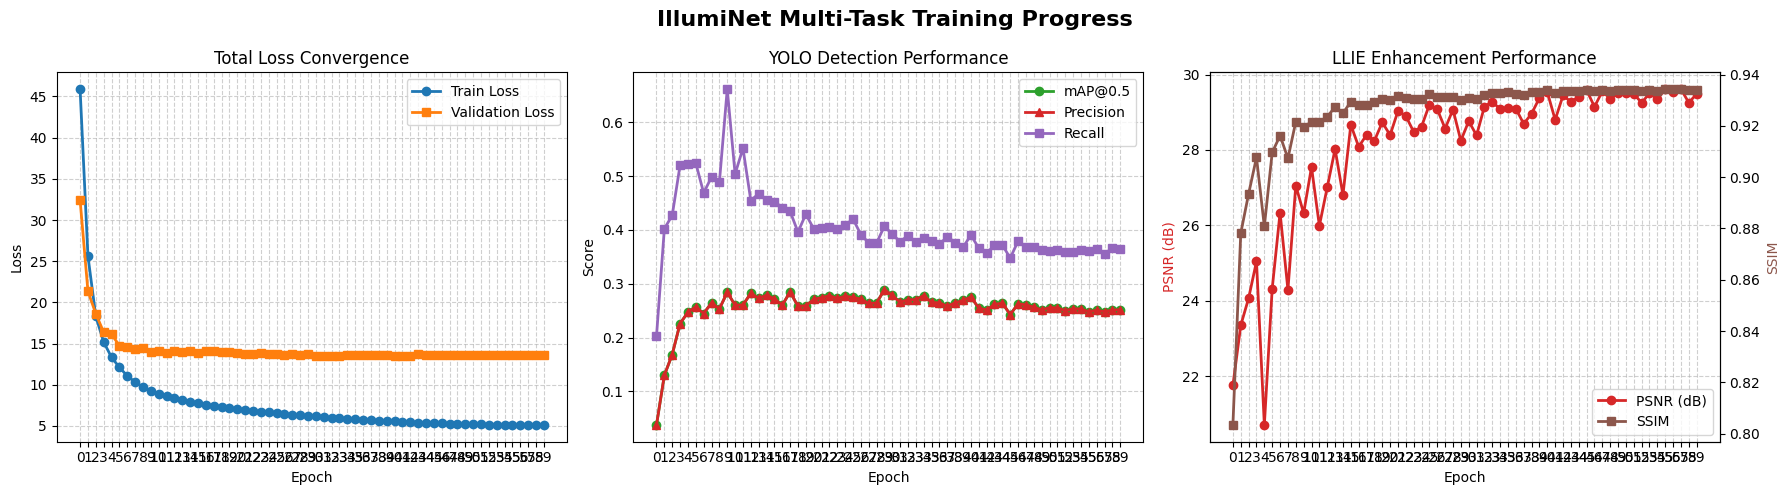

In [9]:
backARB_Scale = IllumiNet_b5_ARB_Scale(back_use_arb=True, dec_arb=False)

backARB_det_loss_fn = DetectionLoss(model=backARB_Scale, device=DEVICE)

backARB_trainer = ModelTrainer(
    model=backARB_Scale, 
    train_loader=train_loader, 
    val_loader=val_loader,
    epochs=60,
    det_loss_fn=backARB_det_loss_fn,
    enhance_loss_fn=mean_abs_error,
    experiment_name='backARB_SS'
)

backARB_hist = backARB_trainer.fit()
backARB_df = pd.DataFrame(backARB_hist)
backARB_df.to_csv('training_hist_backARB_SS.csv', index=False)

visualize_train_plots(training_hist=backARB_hist)

IllumiNet with Scaler Initialized
Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Starting training on cuda for 60 epochs...


Epoch 0/60: 100%|██████████| 638/638 [02:57<00:00,  3.59it/s, TLoss=16.8192, DLoss=27.9857, ELoss=0.0694, LR_BB=1.04e-05, LR_Det=1.04e-05, LR_Dec=1.04e-04] 



🏆 **mAP Improved!** (0.0202 > -inf) at Epoch 0. Saving model.

--- Epoch 0 Summary (177.63s) ---
Train Loss: 49.0754 | Val Loss: 36.4765
Enhancement: PSNR=22.71 | SSIM=0.785
Detection: mAP@0.5=0.020
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [02:57<00:00,  3.60it/s, TLoss=11.0461, DLoss=18.3801, ELoss=0.0452, LR_BB=2.80e-05, LR_Det=2.80e-05, LR_Dec=2.80e-04]



🏆 **mAP Improved!** (0.1214 > 0.0202) at Epoch 1. Saving model.

--- Epoch 1 Summary (177.01s) ---
Train Loss: 28.3643 | Val Loss: 22.9920
Enhancement: PSNR=25.70 | SSIM=0.882
Detection: mAP@0.5=0.121
-------------------------------------------



...


No improvement in mAP (0.2674 ≤ 0.3020). Skipping save.

--- Epoch 57 Summary (177.29s) ---
Train Loss: 5.3709 | Val Loss: 13.8455
Enhancement: PSNR=30.66 | SSIM=0.937
Detection: mAP@0.5=0.267
-------------------------------------------



Epoch 58/60: 100%|██████████| 638/638 [02:57<00:00,  3.59it/s, TLoss=2.8692, DLoss=4.7751, ELoss=0.0104, LR_BB=8.47e-08, LR_Det=8.47e-08, LR_Dec=8.47e-07]



No improvement in mAP (0.2699 ≤ 0.3020). Skipping save.

--- Epoch 58 Summary (177.59s) ---
Train Loss: 5.3619 | Val Loss: 13.8883
Enhancement: PSNR=30.47 | SSIM=0.936
Detection: mAP@0.5=0.270
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [02:57<00:00,  3.59it/s, TLoss=2.7542, DLoss=4.5825, ELoss=0.0117, LR_BB=4.00e-10, LR_Det=4.00e-10, LR_Dec=4.00e-09]



No improvement in mAP (0.2714 ≤ 0.3020). Skipping save.

--- Epoch 59 Summary (177.49s) ---
Train Loss: 5.3685 | Val Loss: 13.8554
Enhancement: PSNR=30.62 | SSIM=0.937
Detection: mAP@0.5=0.271
-------------------------------------------

Training Complete. Final model saved to final_decARB_SS_epoch60.pt


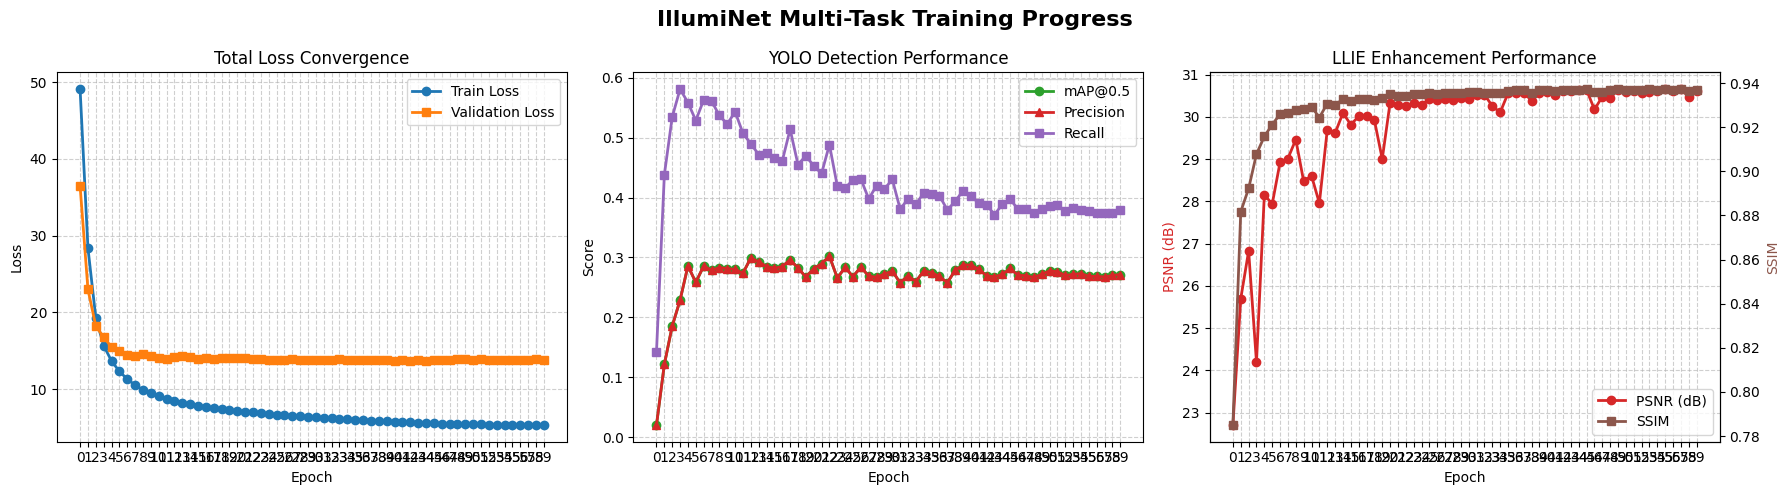

In [10]:
decARB_Scale = IllumiNet_b5_ARB_Scale(back_use_arb=False, dec_arb=True)

decARB_det_loss_fn = DetectionLoss(model=decARB_Scale, device=DEVICE)

decARB_trainer = ModelTrainer(
    model=decARB_Scale, 
    train_loader=train_loader, 
    val_loader=val_loader,
    epochs=60,
    det_loss_fn=decARB_det_loss_fn,
    enhance_loss_fn=mean_abs_error,
    experiment_name='decARB_SS'
)

decARB_hist = decARB_trainer.fit()
decARB_df = pd.DataFrame(decARB_hist)
decARB_df.to_csv('training_hist_decARB_SS.csv', index=False)

visualize_train_plots(training_hist=decARB_hist)

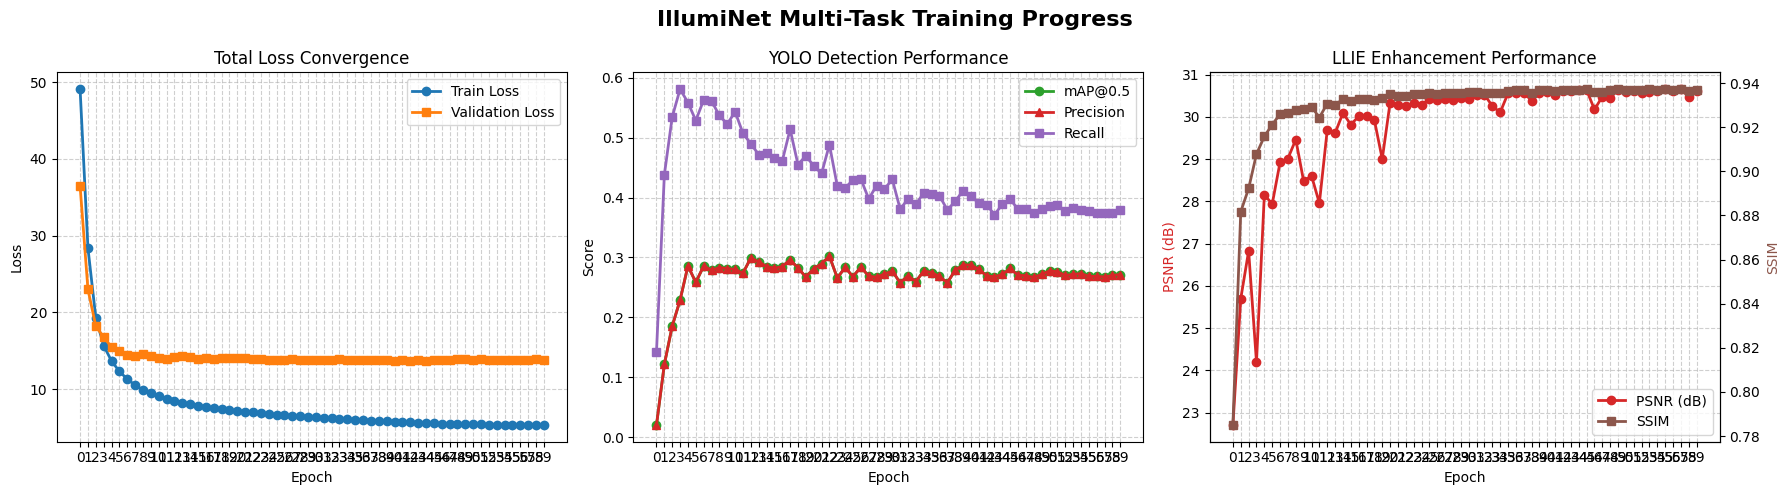

In [11]:
import matplotlib.pyplot as plt 

visualize_train_plots(training_hist=decARB_hist)

In [12]:
# import torch

# print("--- STARTING AUTOPSY ---")

# # 1. Load the exact images that broke the model
# evidence = torch.load("nan_killer_tensors.pt")
# low_imgs = evidence['low_imgs']
# high_imgs = evidence['high_imgs']

# # 2. Put model in eval mode so we don't accidentally train it
# decARB.eval()

# with torch.no_grad():
#     with torch.autocast('cuda'):
        
#         # Step A: Check the raw Decoder output
#         det_out, llie_out, residuals = decARB(low_imgs, inference=True)
        
#         has_nan_output = torch.isnan(llie_out).any().item()
#         print(f"1. Did the Decoder output a NaN? : {has_nan_output}")
        
#         # Step B: Check the Loss Function
#         if not has_nan_output:
#             # Note: You might need to change 'decARB_trainer.enhance_loss_fn' 
#             # to whatever variable holds your actual enhancement loss function
#             enhance_loss = decARB_trainer.enhance_loss_fn(llie_out, high_imgs)
            
#             has_nan_loss = torch.isnan(enhance_loss).any().item()
#             print(f"2. Did the Enhance Loss function create the NaN? : {has_nan_loss}")

# print("--- AUTOPSY COMPLETE ---")

In [13]:
# import torch

# print("--- STARTING DEEP AUTOPSY ---")
# # Load the evidence (added weights_only=False to silence that annoying warning)
# evidence = torch.load("nan_killer_tensors.pt", weights_only=False)
# low_imgs = evidence['low_imgs']

# decARB.eval()

# with torch.no_grad():
#     with torch.autocast('cuda'):
#         # 1. Run Backbone manually
#         # out = decARB.backbone(low_imgs)
#         # dark3 = out['dark3']
#         # dark2 = out['dark2']
#         # stem = out['stem']
#         stem, dark2, dark3, dark4, out = decARB.backbone(low_imgs)
        
        
#         print(f"Backbone Output NaNs -> out: {torch.isnan(out).any().item()} |  Dark4: {torch.isnan(dark4).any().item()} | Dark3: {torch.isnan(dark3).any().item()} | Dark2: {torch.isnan(dark2).any().item()} | Stem: {torch.isnan(stem).any().item()}")

#         # 2. Run Decoder block by block
#         decoder = decARB.decoder

#         # --- UpBlock 1 ---
#         up1_raw = decoder.up_block1(dark3)
#         print(f"UpBlock 1 (Input C -> C/2) NaN? : {torch.isnan(up1_raw).any().item()}")

#         if not torch.isnan(up1_raw).any():
#             # --- UpBlock 2 ---
#             up2_input = up1_raw + dark2
#             up2_raw = decoder.up_block2(up2_input)
#             print(f"UpBlock 2 (Input C/2 -> C/4) NaN? : {torch.isnan(up2_raw).any().item()}")

#             if not torch.isnan(up2_raw).any():
#                 # --- UpBlock 3 ---
#                 up3_input = up2_raw + stem
#                 up3_raw = decoder.up_block3(up3_input)
#                 print(f"UpBlock 3 (Input C/4 -> C/8) NaN? : {torch.isnan(up3_raw).any().item()}")

#                 if not torch.isnan(up3_raw).any():
#                     # --- Final Conv ---
#                     res_map = decoder.final_conv(up3_raw)
#                     print(f"Final Conv NaN? : {torch.isnan(res_map).any().item()}")

# print("--- DEEP AUTOPSY COMPLETE ---")

In [14]:
# import torch

# print("--- STARTING ULTRA-DEEP AUTOPSY ---")
# evidence = torch.load("nan_killer_tensors.pt", weights_only=False)
# low_imgs = evidence['low_imgs']

# decARB.eval()

# with torch.no_grad():
#     with torch.autocast('cuda'):
#         # out = decARB.backbone(low_imgs)
#         stem, dark2, dark3, dark4, out = decARB.backbone(low_imgs)
        
#         x = dark3
        
#         up1 = decARB.decoder.up_block1
        
#         # 1. Step through Residual Blocks
#         for i, res_block in enumerate(up1.residuals):
#             identity = x
            
#             # Main convolutions
#             out_conv = res_block.conv1(x)
#             print(f"ResBlock {i} -> Conv1 NaN? : {torch.isnan(out_conv).any().item()}")
            
#             out_conv = res_block.conv2(out_conv)
#             print(f"ResBlock {i} -> Conv2 NaN? : {torch.isnan(out_conv).any().item()}")
            
#             # ARB Check
#             if res_block.use_arb:
#                 arb = res_block.arb
#                 F_in = arb.f_in(out_conv)
                
#                 F_nc = arb.NCU(F_in)
#                 F_ca = arb.CAU(F_in)
#                 F_sa = arb.SAU(F_in)
                
#                 print(f"ResBlock {i} ARB -> NCU NaN? : {torch.isnan(F_nc).any().item()}")
#                 print(f"ResBlock {i} ARB -> CAU (Channel) NaN? : {torch.isnan(F_ca).any().item()}")
#                 print(f"ResBlock {i} ARB -> SAU (Spatial) NaN? : {torch.isnan(F_sa).any().item()}")
                
#                 out_arb = arb(out_conv)
#                 print(f"ResBlock {i} -> ARB Total Output NaN? : {torch.isnan(out_arb).any().item()}")
#             else:
#                 out_arb = out_conv
            
#             # Final Residual Addition
#             x = out_arb + identity
#             x = torch.nn.functional.silu(x, inplace=True)
#             print(f"ResBlock {i} -> Final Output NaN? : {torch.isnan(x).any().item()}")
#             print("-" * 30)

#         # 2. Deconvolution (Upsampler)
#         x = up1.deconv(x)
#         print(f"Deconv (ConvTranspose2d) NaN? : {torch.isnan(x).any().item()}")

# print("--- ULTRA-DEEP AUTOPSY COMPLETE ---")

IllumiNet with Scaler Initialized
Backbone ARB:  True
Decoder ARB True
Initializing nano params
ARB Backbone Initialized
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Starting training on cuda for 60 epochs...


Epoch 0/60: 100%|██████████| 638/638 [03:14<00:00,  3.28it/s, TLoss=15.8369, DLoss=26.3651, ELoss=0.0446, LR_BB=1.04e-05, LR_Det=1.04e-05, LR_Dec=1.04e-04] 



🏆 **mAP Improved!** (0.0174 > -inf) at Epoch 0. Saving model.

--- Epoch 0 Summary (194.62s) ---
Train Loss: 47.0635 | Val Loss: 66.8238
Enhancement: PSNR=19.65 | SSIM=0.741
Detection: mAP@0.5=0.017
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [03:14<00:00,  3.27it/s, TLoss=10.1113, DLoss=16.8379, ELoss=0.0214, LR_BB=2.80e-05, LR_Det=2.80e-05, LR_Dec=2.80e-04]



🏆 **mAP Improved!** (0.1367 > 0.0174) at Epoch 1. Saving model.

--- Epoch 1 Summary (194.82s) ---
Train Loss: 25.9622 | Val Loss: 21.0435
Enhancement: PSNR=25.30 | SSIM=0.882
Detection: mAP@0.5=0.137
-------------------------------------------



...


No improvement in mAP (0.2496 ≤ 0.3004). Skipping save.

--- Epoch 57 Summary (194.89s) ---
Train Loss: 5.0844 | Val Loss: 13.5880
Enhancement: PSNR=30.55 | SSIM=0.937
Detection: mAP@0.5=0.250
-------------------------------------------



Epoch 58/60: 100%|██████████| 638/638 [03:15<00:00,  3.27it/s, TLoss=2.6723, DLoss=4.4470, ELoss=0.0102, LR_BB=8.47e-08, LR_Det=8.47e-08, LR_Dec=8.47e-07]



No improvement in mAP (0.2516 ≤ 0.3004). Skipping save.

--- Epoch 58 Summary (195.12s) ---
Train Loss: 5.0819 | Val Loss: 13.5567
Enhancement: PSNR=30.61 | SSIM=0.937
Detection: mAP@0.5=0.252
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [03:14<00:00,  3.28it/s, TLoss=2.4908, DLoss=4.1425, ELoss=0.0132, LR_BB=4.00e-10, LR_Det=4.00e-10, LR_Dec=4.00e-09]



No improvement in mAP (0.2514 ≤ 0.3004). Skipping save.

--- Epoch 59 Summary (194.60s) ---
Train Loss: 5.0806 | Val Loss: 13.5764
Enhancement: PSNR=30.54 | SSIM=0.936
Detection: mAP@0.5=0.251
-------------------------------------------

Training Complete. Final model saved to final_bothARB_SS_epoch60.pt


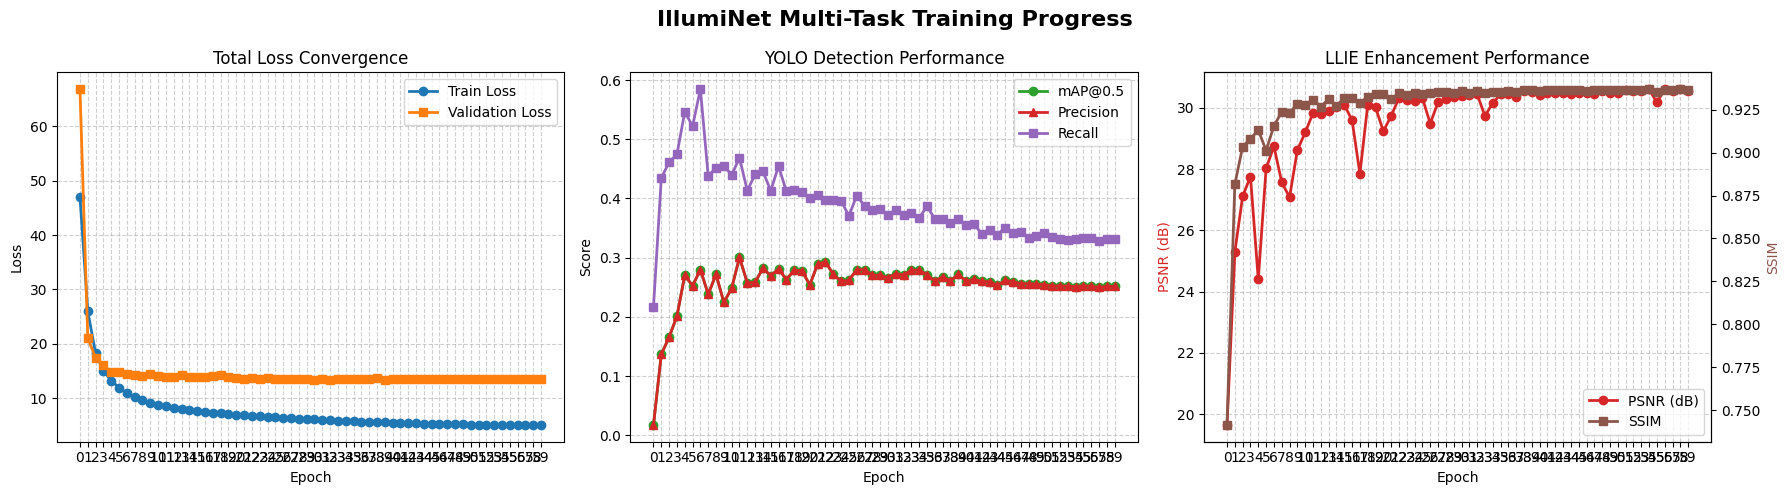

In [15]:
bothARB_Scale = IllumiNet_b5_ARB_Scale(back_use_arb=True, dec_arb=True)

bothARB_det_loss_fn = DetectionLoss(model=bothARB_Scale, device=DEVICE)

bothARB_trainer = ModelTrainer(
    model=bothARB_Scale, 
    train_loader=train_loader, 
    val_loader=val_loader,
    epochs=60,
    det_loss_fn=bothARB_det_loss_fn,
    enhance_loss_fn=mean_abs_error,
    experiment_name='bothARB_SS'
)

bothARB_hist = bothARB_trainer.fit()
bothARB_df = pd.DataFrame(bothARB_hist)
bothARB_df.to_csv('training_hist_bothARB_SS.csv', index=False)

visualize_train_plots(training_hist=bothARB_hist)

In [16]:
# 1. Load your good model from the previous 2-epoch run
checkpoint_path = 'final_baseline_epoch60.pt'
baseline.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))

# 5. Setup a dummy trainer just to use the validate function
test_trainer = ModelTrainer(
    model=baseline,
    train_loader=train_loader,
    val_loader=test_loader, # Or test_loader
    epochs=0,              # We aren't training!
    det_loss_fn=def_det_loss_fn,
    enhance_loss_fn=mean_abs_error,
    device=DEVICE
)

# 3. Force it to run validation
print("Running validation on Epoch 60 weights...")
val_metrics = test_trainer.validate()

print(f"\n--- Validation Results ---")
print(f"Loop mAP@0.5: {val_metrics['val_mAP50']:.3f}")

NameError: name 'baseline' is not defined

In [ ]:
val_metrics

{'val_loss_total': 14.547564657110916,
 'val_loss_det': 24.23352279161152,
 'val_loss_enh': 0.01862597379735426,
 'val_psnr': 28.493905067443848,
 'val_ssim': np.float32(0.93285847),
 'val_prec_prox': 0.1757541447877884,
 'val_mAP50': 0.1757541447877884,
 'val_mAP': 0.1757541447877884,
 'val_recall': 0.27126163244247437}

Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Loading direct state dictionary...
Model loaded successfully!
--- Visualizing Random Sample Index: 186 ---


C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_4180\465197622.py:458: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_lo


=== METRICS: Image 186 ===
PSNR      : 26.17
SSIM      : 0.8908
Precision : 0.800
Recall    : 0.667
mAP@50    : 0.533


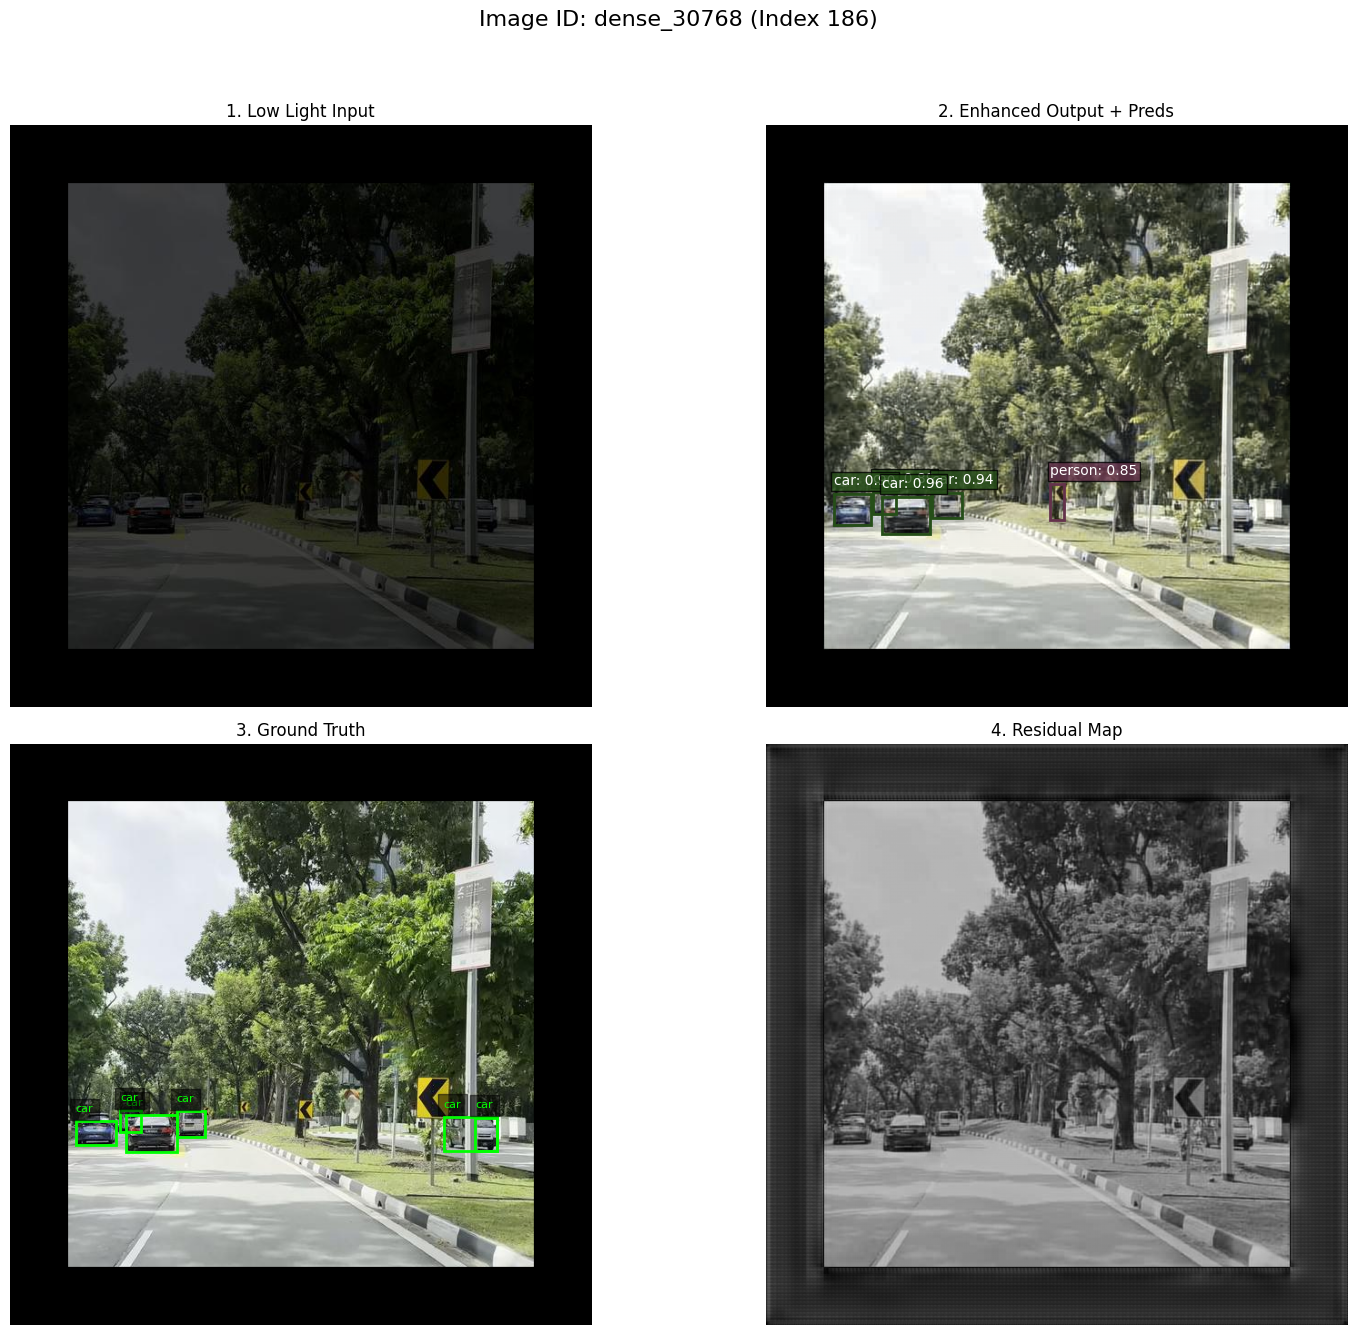

In [ ]:
def load_classes_as_dict(path):
    """
    Loads a class file of format:
    0: person
    1: bicycle
    ...
    And returns:
    {0: 'person', 1: 'bicycle', ...}
    """
    classes = {}
    
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue   # skip empty lines
            
            # Split ONLY at the first ":" (safe even if names contain ":")
            idx, name = line.split(":", 1)
            idx = int(idx.strip())
            name = name.strip()
            
            classes[idx] = name
    
    return classes

from torchvision.ops import box_iou
import numpy as np
from post_processing.det_postprocess import Detections
from losses.llie_loss import psnr, ssim_metric
from tqdm import tqdm

# 1. Define Robust Precision/Recall Helper
def compute_precision_recall_robust(detections, gt_boxes, iou_thresh=0.5):
    """
    Robust calculation of P/R that handles empty or single-item tensors correctly.
    """
    # A. Prepare Prediction Boxes
    if len(detections) == 0:
        pred_boxes = torch.empty((0, 4))
    else:
        # Convert supervision numpy -> torch
        pred_boxes = torch.from_numpy(detections.xyxy).float()

    # B. Prepare GT Boxes
    gt_boxes = gt_boxes.cpu().float()
    pred_boxes = pred_boxes.cpu()

    # C. SAFETY: Force 2D shapes [N, 4] to prevent box_iou crash on single boxes
    if pred_boxes.dim() == 1: 
        pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: 
        gt_boxes = gt_boxes.unsqueeze(0)

    # D. Edge Cases (Empty inputs)
    if len(gt_boxes) == 0:
        # If no GT, but we have preds -> Precision 0, Recall 0 (technically undefined)
        # If no GT, and no preds -> Perfect (1.0)
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    
    if len(pred_boxes) == 0:
        # GT exists, but no preds -> Precision 0, Recall 0
        return 0.0, 0.0

    # E. Calculate IoU
    # box_iou requires (N,4) inputs
    ious = box_iou(pred_boxes, gt_boxes) 

    # F. Compute Metrics (Simple Greedy Matching)
    
    # Precision: What % of Predictions matched a GT?
    # For each Pred, did it hit ANY GT?
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall: What % of GTs were detected?
    # For each GT, was it hit by ANY Pred?
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall

def inference_visualization_mpl(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict):
    """
    Runs model inference, applies detection post-processing, and visualizes the 4 outputs 
    using a single Matplotlib figure with 4 subplots.
    """
    
    model.eval()
    device = next(model.parameters()).device
    
    print(f"--- Starting Visualization on Device: {device} ---")
    test_pbar = tqdm(test_loader, desc="Visualizing", leave=False)
    
    # Simple color map for visualization
    def get_color(cls_id, N): 
        # Generates a distinct color based on class ID
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        # Clamp to [0, 1], move to CPU, HWC format (RGB) for Matplotlib
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        for batch_idx, batch_data in enumerate(test_pbar):
            
            low_imgs = batch_data['images_low'].to(device)
            
            # --- Model Forward Pass (Inference=True) ---
            det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
            
            # --- Process Batch Image by Image ---
            for i in range(det_out.size(0)):
                
                # A. Detection Post-Processing
                
                # 1. Transpose to [N_boxes, C_data]
                preds_i = det_out[i].transpose(0, 1).contiguous() 

                # 2. Extract components
                boxes_xywh = preds_i[:, :4] # Model output is xywh
                cls_probs = preds_i[:, 4:]   # Class scores

                # 3. Get confidences and class indices
                confidences, class_indices = torch.max(cls_probs, dim=1)
                
                # 4. Convert coordinates
                boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
                
                # 5. Filter by threshold
                CONF_THRESH = 0.75
                mask = confidences > CONF_THRESH
                
                if not mask.any(): 
                    detections = Detections.empty()
                else:
                    # 6. Create the final tensor [xyxy, conf, cls]
                    final_preds = torch.cat((
                        boxes_xyxy[mask], 
                        confidences[mask].unsqueeze(1), 
                        class_indices[mask].float().unsqueeze(1)
                    ), dim=1)
                    
                    # 7. Create Detections object
                    detections = Detections.from_yolo(final_preds)
                
                # B. Post-Processing: Rescale Boxes
                if len(detections) > 0:
                    detections = detections.with_nms(threshold=0.5)

                # C. Prepare Images for Display
                img_low_mpl = tensor_to_mpl(low_imgs[i])
                img_enhanced_mpl = tensor_to_mpl(llie_out[i])
                img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
                residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
                residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

                # D. Visualization Plotting
                fig = plt.figure(figsize=(16, 14))
                fig.suptitle(f"Batch {batch_idx}, Image {i} Visualization", fontsize=16)
                
                # --- Plot 1: Low Light Input ---
                ax1 = fig.add_subplot(2, 2, 1)
                ax1.imshow(img_low_mpl)
                ax1.set_title('1. Low Light Input (I)')
                ax1.axis('off')
                
                # --- Plot 2: Enhanced Output with Detections ---
                ax2 = fig.add_subplot(2, 2, 2)
                ax2.imshow(img_enhanced_mpl)
                ax2.set_title('2. Enhanced Output (R) + Detections')
                ax2.axis('off')
                
                # Draw boxes on ax2
                if len(detections) > 0:
                    for box, _, conf, cls, _ in detections:
                        x1, y1, x2, y2 = box.astype(int)
                        
                        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                                 linewidth=2, 
                                                 edgecolor=get_color(int(cls), len(class_names)), 
                                                 facecolor='none')
                        ax2.add_patch(rect)
                        
                        label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                        ax2.text(x1, y1 - 10, label, color='white', 
                                 bbox={'facecolor': get_color(int(cls), len(class_names)), 
                                       'alpha': 0.8, 'pad': 2, 'edgecolor': 'none'})
                
                # --- Plot 3: Ground Truth High Light (G) ---
                ax3 = fig.add_subplot(2, 2, 3)
                ax3.imshow(img_gt_mpl)
                ax3.set_title('3. Ground Truth High Light (G)')
                ax3.axis('off')
                
                # --- NEW: PREPARE AND DRAW GT BOXES ---
                
                # 1. Setup variables
                all_batch_indices = batch_data['batch_idx'].to(device)
                all_bboxes = batch_data['bboxes'].to(device)
                all_cls = batch_data['cls'].to(device)
                
                mask_i = (all_batch_indices == i)
                gt_bboxes_xywh = all_bboxes[mask_i]
                gt_cls = all_cls[mask_i]
                
                pads = batch_data["padding_high"][i]
                
                # Define padded_image specifically for this loop iteration
                padded_image = batch_data['images_high'][i]
                padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]

                # Initialize empty GT tensor on DEVICE
                gt_boxes_xyxy = torch.empty((0, 4), device=device)

                if gt_bboxes_xywh.numel() > 0:
                    # Convert normalized xywh -> absolute xyxy in PADDED space
                    boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                    boxes_abs[:, [0, 2]] *= padded_w
                    boxes_abs[:, [1, 3]] *= padded_h
                    
                    gt_boxes_xyxy = boxes_abs

                    # Draw boxes on Matplotlib
                    for j, box in enumerate(boxes_abs):
                        x1, y1, x2, y2 = box.int().tolist()
                        
                        rect = patches.Rectangle(
                            (x1, y1), x2 - x1, y2 - y1,
                            linewidth=2, edgecolor='lime', facecolor='none'
                        )
                        ax3.add_patch(rect)

                        cls_name = class_names.get(int(gt_cls[j]), "GT")
                        ax3.text(
                            x1, y1 - 10, cls_name,
                            color='lime', fontsize=8,
                            bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 2}
                        )
                
                # --- Plot 4: Residual Map (R - I) ---
                ax4 = fig.add_subplot(2, 2, 4)
                ax4.imshow(residual_vis_mpl)
                ax4.set_title('4. LLIE Residual Map (Magnitude)')
                ax4.axis('off')

                # --- Compute image metrics ---
                
                # Move GT image to DEVICE for PSNR/SSIM
                gt_image = batch_data['images_high'][i].to(device)

                img_psnr = psnr(
                    llie_out[i].unsqueeze(0),
                    gt_image.unsqueeze(0)
                ).item()

                img_ssim = ssim_metric(llie_out[i], gt_image)

                # *** FIX: Move GT boxes to CPU for compatibility with Detections (which are CPU/Numpy) ***
                precision_i, recall_i = compute_precision_recall(detections, gt_boxes_xyxy.cpu())
                map50_i = precision_i * recall_i 

                print(f"\n=== METRICS FOR THIS IMAGE ===")
                print(f"PSNR      : {img_psnr:.2f} dB")
                print(f"SSIM      : {img_ssim:.4f}")
                print(f"Precision : {precision_i:.3f}")
                print(f"Recall    : {recall_i:.3f}")
                print(f"mAP@50    : {map50_i:.3f}")

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                plt.show() 
                
                # Stop after one image
                if batch_idx >= 0 and i >= 0: 
                    break 
            
            # Stop after one batch
            if batch_idx == 0:
                break 
                  
    print("--- Visualization Complete ---")

def xywh2xyxy_tensor(xywh:torch.Tensor):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = torch.chunk(xywh, 2, dim=-1)
    return torch.cat((xy - wh / 2, xy + wh / 2), dim=-1)

def visualize_random_sample(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict, rand_idx):
    """
    Picks ONE random image from the dataset, runs inference, and visualizes the result.
    """
    
    model.eval()
    device = next(model.parameters()).device
    dataset = test_loader.dataset
    
    # 1. Pick a Random Index
    # rand_idx = random.randint(0, len(dataset) - 1)
    print(f"--- Visualizing Random Sample Index: {rand_idx} ---")

    # 2. Fetch the single sample and Collate it into a batch of size 1
    # We use the loader's own collate_fn to ensure data structure matches exactly
    single_sample = dataset[rand_idx]
    batch_data = test_loader.collate_fn([single_sample])

    # 3. Simple color map & Helper
    def get_color(cls_id, N): 
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        # Move inputs to device
        low_imgs = batch_data['images_low'].to(device)
        
        # --- Model Forward Pass ---
        det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
        
        # We know batch size is 1, so i is always 0
        i = 0 
        
        # A. Detection Post-Processing
        preds_i = det_out[i].transpose(0, 1).contiguous() 
        boxes_xywh = preds_i[:, :4]
        cls_probs = preds_i[:, 4:]  
        confidences, class_indices = torch.max(cls_probs, dim=1)
        
        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
        
        CONF_THRESH = 0.50 # You can adjust this
        mask = confidences > CONF_THRESH
        
        if not mask.any(): 
            detections = Detections.empty()
            print("No detections above threshold.")
        else:
            final_preds = torch.cat((
                boxes_xyxy[mask], 
                confidences[mask].unsqueeze(1), 
                class_indices[mask].float().unsqueeze(1)
            ), dim=1)
            detections = Detections.from_yolo(final_preds).with_nms(threshold=0.5)

        # B. Prepare Images
        img_low_mpl = tensor_to_mpl(low_imgs[i])
        img_enhanced_mpl = tensor_to_mpl(llie_out[i])
        img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
        residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
        residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

        # C. Visualization Plotting
        fig = plt.figure(figsize=(16, 14))
        img_name = batch_data['im_id'][i]
        fig.suptitle(f"Image ID: {img_name} (Index {rand_idx})", fontsize=16)
        
        # Plot 1: Low Light
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(img_low_mpl)
        ax1.set_title('1. Low Light Input')
        ax1.axis('off')
        
        # Plot 2: Enhanced + Detections
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.imshow(img_enhanced_mpl)
        ax2.set_title('2. Enhanced Output + Preds')
        ax2.axis('off')
        
        if len(detections) > 0:
            for box, _, conf, cls, _ in detections:
                x1, y1, x2, y2 = box.astype(int)
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, 
                                         edgecolor=get_color(int(cls), len(class_names)), facecolor='none')
                ax2.add_patch(rect)
                label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                ax2.text(x1, y1 - 10, label, color='white', 
                         bbox={'facecolor': get_color(int(cls), len(class_names)), 'alpha': 0.8, 'pad': 2})
        
        # Plot 3: Ground Truth
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.imshow(img_gt_mpl)
        ax3.set_title('3. Ground Truth')
        ax3.axis('off')
        
        # --- GT BOX LOGIC ---
        all_indices = batch_data['batch_idx'].to(device)
        all_bboxes = batch_data['bboxes'].to(device)
        all_cls = batch_data['cls'].to(device)
        
        mask_i = (all_indices == i) # Should be all True since batch size is 1
        gt_bboxes_xywh = all_bboxes[mask_i]
        gt_cls = all_cls[mask_i]
        
        padded_image = batch_data['images_high'][i]
        padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
        
        gt_boxes_xyxy = torch.empty((0, 4), device=device)

        if gt_bboxes_xywh.numel() > 0:
            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
            boxes_abs[:, [0, 2]] *= padded_w
            boxes_abs[:, [1, 3]] *= padded_h
            gt_boxes_xyxy = boxes_abs

            for j, box in enumerate(boxes_abs):
                x1, y1, x2, y2 = box.int().tolist()
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
                ax3.add_patch(rect)
                cls_name = class_names.get(int(gt_cls[j]), "GT")
                ax3.text(x1, y1 - 10, cls_name, color='lime', fontsize=8, bbox={'facecolor': 'black', 'alpha': 0.5})

        # Plot 4: Residual
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.imshow(residual_vis_mpl)
        ax4.set_title('4. Residual Map')
        ax4.axis('off')

        # D. Metrics
        gt_image = batch_data['images_high'][i].to(device)
        img_psnr = psnr(llie_out[i].unsqueeze(0), gt_image.unsqueeze(0)).item()
        img_ssim = ssim_metric(llie_out[i], gt_image)
        if isinstance(img_ssim, torch.Tensor): img_ssim = img_ssim.item()
        
        # Robust Precision/Recall using the fixed function from before
        precision_i, recall_i = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
        map50_i = precision_i * recall_i 
        
        print(f"\n=== METRICS: Image {rand_idx} ===")
        print(f"PSNR      : {img_psnr:.2f}")
        print(f"SSIM      : {img_ssim:.4f}")
        print(f"Precision : {precision_i:.3f}")
        print(f"Recall    : {recall_i:.3f}")
        print(f"mAP@50    : {map50_i:.3f}")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Usage:
# visualize_random_sample(model, test_loader, CLASSES_TO_DETECT)
model = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=False)

# checkpoint_path = 'final_baseline_epoch60.pt'

# checkpoint_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\run_weights_NEWEST\best_baseline_mAP.pt'
checkpoint_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_backARB_mAP.pt'
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    # Case A: You saved {'epoch': ..., 'model_state_dict': ...}
    print("Loading from full checkpoint dictionary...")
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    # Case B: You saved model.state_dict() directly
    print("Loading direct state dictionary...")
    model.load_state_dict(checkpoint)

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print("Model loaded successfully!")

CLASSES_TO_DETECT = load_classes_as_dict(CLASSES_FILE)
# inference_visualization_mpl(model=model, test_loader=test_loader, class_names=CLASSES_TO_DETECT)
visualize_random_sample(model=model, test_loader=test_loader, class_names=CLASSES_TO_DETECT, rand_idx=186)

In [ ]:
from torchvision.ops import nms
# import torch
# from tqdm import tqdm

from torchvision.ops import box_iou

def compute_pr_tensor(pred_boxes: torch.Tensor, gt_boxes: torch.Tensor, iou_thresh=0.5):
    """
    Pure-tensor calculation of Precision and Recall.
    No Detections objects or numpy arrays required.
    """
    # Move everything to CPU safely
    pred_boxes = pred_boxes.cpu().float()
    gt_boxes = gt_boxes.cpu().float()
    
    # SAFETY: Force 2D shapes [N, 4]
    if pred_boxes.dim() == 1: pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: gt_boxes = gt_boxes.unsqueeze(0)

    if len(gt_boxes) == 0:
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    if len(pred_boxes) == 0:
        return 0.0, 0.0

    # Calculate IoU
    ious = box_iou(pred_boxes, gt_boxes) 

    # Precision
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall

def find_best_nms_threshold(model, val_loader, device, conf_thresh=0.01):
    """
    Tests multiple NMS IoU thresholds simultaneously to find the optimal balance
    for occluded/overlapping objects.
    """
    model.eval()
    
    # The thresholds we want to test (0.4 is strict, 0.8 allows heavy overlap)
    nms_thresholds = [0.40, 0.50, 0.60, 0.70, 0.80]
    
    # Dictionary to hold the running metrics for each threshold
    results = {nms_val: {'precision': 0.0, 'recall': 0.0, 'map50': 0.0, 'count': 0} for nms_val in nms_thresholds}
    
    print(f"--- Running NMS Sweep on Device: {device} ---")
    
    with torch.no_grad():
        for batch_data in tqdm(val_loader, desc="Testing NMS Variants"):
            low_imgs = batch_data['images_low'].to(device)
            B, _, H, W = low_imgs.shape
            
            # 1. Forward Pass
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                det_out, _, _ = model(low_imgs, inference=True)
            
            for b in range(B):
                # Extract raw predictions for this image
                p = det_out[b].permute(1, 0)
                boxes_xywh = p[:, :4]
                cls_scores, labels = p[:, 4:].max(dim=1)
                
                # Convert xywh to xyxy
                pred_xy = boxes_xywh[:, :2]
                pred_wh = boxes_xywh[:, 2:]
                boxes_xyxy = torch.cat((pred_xy - pred_wh / 2, pred_xy + pred_wh / 2), dim=1)
                
                # Filter by base confidence
                mask = cls_scores > conf_thresh
                base_boxes, base_scores = boxes_xyxy[mask], cls_scores[mask]
                
                # Extract Ground Truth for this image
                gt_mask = batch_data['batch_idx'].to(device) == b
                gt_boxes_xywh = batch_data['bboxes'].to(device)[gt_mask]
                
                if len(gt_boxes_xywh) > 0:
                    gt_xy = gt_boxes_xywh[:, :2]
                    gt_wh = gt_boxes_xywh[:, 2:]
                    gt_boxes_xyxy = torch.cat((gt_xy - gt_wh / 2, gt_xy + gt_wh / 2), dim=1)
                    gt_boxes_xyxy[:, [0, 2]] *= W
                    gt_boxes_xyxy[:, [1, 3]] *= H
                else:
                    gt_boxes_xyxy = torch.empty((0, 4), device=device)
                
                # 2. Test EVERY NMS threshold on these exact same raw boxes
                for nms_val in nms_thresholds:
                    if len(base_boxes) > 0:
                        keep = nms(base_boxes, base_scores, iou_threshold=nms_val)
                        final_boxes = base_boxes[keep]
                    else:
                        final_boxes = base_boxes
                        
                    # Compute P/R using your robust manual function
                    prec, rec = compute_pr_tensor(final_boxes, gt_boxes_xyxy, iou_thresh=0.5)
                    
                    results[nms_val]['precision'] += prec
                    results[nms_val]['recall'] += rec
                    results[nms_val]['map50'] += (prec * rec)
                    results[nms_val]['count'] += 1

    # 3. Print the Final Table
    print("\n" + "="*55)
    print(f"{'NMS Threshold':<15} | {'Precision':<10} | {'Recall':<10} | {'mAP@50':<10}")
    print("="*55)
    
    for nms_val in nms_thresholds:
        count = results[nms_val]['count']
        avg_p = results[nms_val]['precision'] / count if count > 0 else 0
        avg_r = results[nms_val]['recall'] / count if count > 0 else 0
        avg_map = results[nms_val]['map50'] / count if count > 0 else 0
        
        print(f"{nms_val:<15.2f} | {avg_p:<10.4f} | {avg_r:<10.4f} | {avg_map:<10.4f}")
    print("="*55)

# Run it!
find_best_nms_threshold(baseline, test_loader, DEVICE)

--- Running NMS Sweep on Device: cuda ---


Testing NMS Variants: 100%|██████████| 38/38 [00:03<00:00, 11.24it/s]


NMS Threshold   | Precision  | Recall     | mAP@50    
0.40            | 0.6827     | 0.7938     | 0.5562    
0.50            | 0.6720     | 0.8042     | 0.5532    
0.60            | 0.6650     | 0.8073     | 0.5495    
0.70            | 0.6646     | 0.8136     | 0.5513    
0.80            | 0.6704     | 0.8179     | 0.5593    


In [ ]:
# class ModelEvaluator:
#     def __init__(self, test_loader, device):
#         self.test_loader = test_loader
#         self.device = device
    
#     def evaluate(self, model, weight_path, model_name="Unknown"):
#         # 1. Load Weights
#         print(f"Loading weights for {model_name} from: {weight_path}")
#         try:
#             checkpoint = torch.load(weight_path, map_location=self.device)
#             # Handle if weights are in 'model_state_dict' or just the dict directly
#             state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
#             model.load_state_dict(state_dict)
#         except Exception as e:
#             print(f"Error loading {weight_path}: {e}")
#             return None

#         model.to(self.device)
#         model.eval()
        
#         # Metrics Accumulators
#         metrics = {
#             'psnr': [],
#             'ssim': [],
#             'precision': [],
#             'recall': [],
#             'map50': []
#         }
        
#         pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
#         with torch.no_grad():
#             for batch_data in pbar:
#                 low_imgs = batch_data['images_low'].to(self.device)
                
#                 # Inference
#                 det_out, llie_out, _ = model(low_imgs, inference=True)
                
#                 # --- Per Image Processing in Batch ---
#                 for i in range(det_out.size(0)):
#                     # ================================
#                     # 1. IMAGE METRICS (PSNR / SSIM)
#                     # ================================
#                     gt_image = batch_data['images_high'][i].to(self.device)
#                     enhanced_image = llie_out[i]
                    
#                     # PSNR
#                     val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
#                     metrics['psnr'].append(val_psnr)
                    
#                     # SSIM
#                     val_ssim = ssim_metric(enhanced_image, gt_image) # Assumes input is (C, H, W) or (1, C, H, W)
#                     # Handle if ssim returns tensor
#                     if isinstance(val_ssim, torch.Tensor):
#                         val_ssim = val_ssim.item()
#                     metrics['ssim'].append(val_ssim)

#                     # ================================
#                     # 2. DETECTION METRICS
#                     # ================================
                    
#                     # --- PREPARE PREDICTIONS ---
#                     preds_i = det_out[i].transpose(0, 1).contiguous()
#                     boxes_xywh = preds_i[:, :4]
#                     cls_probs = preds_i[:, 4:]
#                     confidences, class_indices = torch.max(cls_probs, dim=1)
                    
#                     boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                    
#                     CONF_THRESH = 0.50 # Standard eval threshold, adjust if needed
#                     mask = confidences > CONF_THRESH
                    
#                     if not mask.any():
#                         detections = Detections.empty()
#                     else:
#                         final_preds = torch.cat((
#                             boxes_xyxy[mask], 
#                             confidences[mask].unsqueeze(1), 
#                             class_indices[mask].float().unsqueeze(1)
#                         ), dim=1)
#                         detections = Detections.from_yolo(final_preds)
#                         detections = detections.with_nms(threshold=0.5)

#                     # --- PREPARE GROUND TRUTH ---
#                     all_indices = batch_data['batch_idx'].to(self.device)
#                     all_bboxes = batch_data['bboxes'].to(self.device)
#                     all_cls = batch_data['cls'].to(self.device)
                    
#                     # Filter for current image
#                     mask_i = (all_indices == i)
#                     gt_bboxes_xywh = all_bboxes[mask_i]
                    
#                     padded_image = batch_data['images_high'][i]
#                     padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
                    
#                     gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                    
#                     if gt_bboxes_xywh.numel() > 0:
#                         # Normalize -> Absolute Padded Coordinates
#                         boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
#                         boxes_abs[:, [0, 2]] *= padded_w
#                         boxes_abs[:, [1, 3]] *= padded_h
#                         gt_boxes_xyxy = boxes_abs

#                     # --- COMPUTE DETECTION METRICS ---
#                     # Move to CPU for compatibility if using supervision or numpy based IoU
#                     prec, rec = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
                    
#                     metrics['precision'].append(prec)
#                     metrics['recall'].append(rec)
#                     metrics['map50'].append(prec * rec) # Simple mAP estimation

#         # Calculate Averages
#         summary = {k: np.mean(v) for k, v in metrics.items()}
#         print(f"Results {model_name}: {summary}")
#         return summary

import torch
import numpy as np
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import nms



class ModelEvaluator:
    def __init__(self, test_loader, device, min_area=None):
        self.test_loader = test_loader
        self.device = device
        
        # PROFESSOR's FILTER: Minimum bounding box area (in pixels) to evaluate.
        # Set to 1024 to ignore all COCO "Small" objects. Set to None to evaluate everything.
        self.min_area = min_area 
        
        # Initialize torchmetrics strictly for IoU = 0.50!
        # This forces map, map_small, map_medium, and map_large to ALL be evaluated at 50% overlap.
        self.map_metric = MeanAveragePrecision(
            box_format='xyxy',
            iou_type='bbox',
            iou_thresholds=[0.5],
            max_detection_thresholds=[10, 100, 500]
        ).to(device)
    
    def evaluate(self, model, weight_path, model_name="Unknown"):
        print(f"\nLoading weights for {model_name} from: {weight_path}")
        try:
            checkpoint = torch.load(weight_path, map_location=self.device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Error loading {weight_path}: {e}")
            return None

        model.to(self.device)
        model.eval()
        
        self.map_metric.reset()
        
        metrics = {'psnr': [], 'ssim': []}
        
        pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
        with torch.no_grad():
            with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                for batch_data in pbar:
                    low_imgs = batch_data['images_low'].to(self.device)
                    high_imgs = batch_data['images_high'].to(self.device)
                    
                    B, _, H, W = low_imgs.shape 

                    # Inference
                    det_out, llie_out, _ = model(low_imgs, inference=True)
                    
                    preds, targets = [], []

                    for i in range(B):
                        # ================================
                        # 1. IMAGE METRICS (PSNR / SSIM)
                        # ================================
                        gt_image = high_imgs[i]
                        enhanced_image = llie_out[i]
                        
                        val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
                        metrics['psnr'].append(val_psnr)
                        
                        val_ssim = ssim_metric(enhanced_image, gt_image) 
                        if isinstance(val_ssim, torch.Tensor):
                            val_ssim = val_ssim.item()
                        metrics['ssim'].append(val_ssim)

                        # ================================
                        # 2. DETECTION METRICS
                        # ================================
                        
                        # --- PREDICTIONS ---
                        p = det_out[i].transpose(0, 1).contiguous()
                        boxes_xywh = p[:, :4]
                        cls_probs = p[:, 4:]
                        confidences, class_indices = torch.max(cls_probs, dim=1)
                        
                        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                        
                        # Keep confidence low (0.001) for accurate PR Curve generation
                        mask = confidences > 0.5
                        pred_boxes = boxes_xyxy[mask]
                        pred_scores = confidences[mask]
                        pred_labels = class_indices[mask]
                        
                        if len(pred_boxes) > 0:
                            # Apply your proven NMS threshold
                            keep = nms(pred_boxes, pred_scores, 0.45)
                            pred_boxes = pred_boxes[keep]
                            pred_scores = pred_scores[keep]
                            pred_labels = pred_labels[keep]
                            
                            # PROFESSOR'S FILTER (Predictions)
                            if self.min_area is not None:
                                areas = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
                                valid_mask = areas >= self.min_area
                                pred_boxes = pred_boxes[valid_mask]
                                pred_scores = pred_scores[valid_mask]
                                pred_labels = pred_labels[valid_mask]

                        preds.append({
                            "boxes": pred_boxes,
                            "scores": pred_scores,
                            "labels": pred_labels
                        })

                        # --- GROUND TRUTH ---
                        all_indices = batch_data['batch_idx'].to(self.device)
                        all_bboxes = batch_data['bboxes'].to(self.device)
                        all_cls = batch_data['cls'].to(self.device)
                        
                        mask_i = (all_indices == i)
                        gt_bboxes_xywh = all_bboxes[mask_i]
                        gt_labels = all_cls[mask_i]
                        
                        gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                        
                        if gt_bboxes_xywh.numel() > 0:
                            # Normalize -> Absolute Coordinates
                            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                            boxes_abs[:, [0, 2]] *= W
                            boxes_abs[:, [1, 3]] *= H
                            gt_boxes_xyxy = boxes_abs
                            
                            # PROFESSOR'S FILTER (Ground Truth)
                            if self.min_area is not None:
                                areas = (gt_boxes_xyxy[:, 2] - gt_boxes_xyxy[:, 0]) * (gt_boxes_xyxy[:, 3] - gt_boxes_xyxy[:, 1])
                                valid_mask = areas >= self.min_area
                                gt_boxes_xyxy = gt_boxes_xyxy[valid_mask]
                                gt_labels = gt_labels[valid_mask]

                        targets.append({
                            "boxes": gt_boxes_xyxy,
                            "labels": gt_labels
                        })

                    # Update torchmetrics object with batch data
                    self.map_metric.update(preds, targets)

        # Compute final detection metrics
        map_results = self.map_metric.compute()
        
        # Build Summary Dictionary
        summary = {
            'psnr': np.mean(metrics['psnr']),
            'ssim': np.mean(metrics['ssim']),
            'mAP@50_Total': map_results['map'].item(),       # This is strictly @50 now!
            'mAP@50_Small': map_results['map_small'].item(),
            'mAP@50_Medium': map_results['map_medium'].item(),
            'mAP@50_Large': map_results['map_large'].item()
        }
        
        # Clean up missing data (-1 means no objects of that size were present)
        for k, v in summary.items():
            if v == -1: summary[k] = 0.0

        print(f"\n--- Results for {model_name} ---")
        for key, value in summary.items():
            print(f"{key:>15}: {value:.4f}")
            
        return summary


class GranularModelEvaluator:
    # Added class_names dictionary so it prints "Car" instead of "Class 2"
    def __init__(self, test_loader, device, min_area=None, class_names=None):
        self.test_loader = test_loader
        self.device = device
        self.min_area = min_area 
        self.class_names = class_names or {} # e.g., {0: 'person', 1: 'bicycle', 2: 'car'}
        
        self.map_metric = MeanAveragePrecision(
            box_format='xyxy',
            iou_type='bbox',
            iou_thresholds=[0.5],
            max_detection_thresholds=[10, 100, 500],
            class_metrics=True  # <--- THIS UNLOCKS CLASS-SPECIFIC MAP
        ).to(device)
    
    def evaluate(self, model, weight_path, model_name="Unknown"):
        print(f"\nLoading weights for {model_name} from: {weight_path}")
        try:
            checkpoint = torch.load(weight_path, map_location=self.device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Error loading {weight_path}: {e}")
            return None

        model.to(self.device)
        model.eval()
        self.map_metric.reset()
        
        # New Granular Dictionaries
        metrics = {
            'psnr': {'all': [], 'light': [], 'moderate': [], 'dense': []},
            'ssim': {'all': [], 'light': [], 'moderate': [], 'dense': []}
        }
        
        pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
        with torch.no_grad():
            with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                for batch_data in pbar:
                    low_imgs = batch_data['images_low'].to(self.device)
                    high_imgs = batch_data['images_high'].to(self.device)
                    B, _, H, W = low_imgs.shape 

                    det_out, llie_out, _ = model(low_imgs, inference=True)
                    preds, targets = [], []

                    for i in range(B):
                        # --- DETERMINE SCENE DENSITY ---
                        # Count the number of Ground Truth boxes before filtering
                        all_indices = batch_data['batch_idx'].to(self.device)
                        mask_i = (all_indices == i)
                        num_objects = mask_i.sum().item()
                        
                        # Tweak these thresholds based on your dataset!
                        if num_objects <= 10:
                            density = 'light'
                        elif num_objects <= 30:
                            density = 'moderate'
                        else:
                            density = 'dense'

                        # ================================
                        # 1. IMAGE METRICS (PSNR / SSIM)
                        # ================================
                        gt_image = high_imgs[i]
                        enhanced_image = llie_out[i]
                        
                        val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
                        val_ssim = ssim_metric(enhanced_image, gt_image) 
                        if isinstance(val_ssim, torch.Tensor): val_ssim = val_ssim.item()
                        
                        metrics['psnr']['all'].append(val_psnr)
                        metrics['psnr'][density].append(val_psnr)
                        metrics['ssim']['all'].append(val_ssim)
                        metrics['ssim'][density].append(val_ssim)

                        # ================================
                        # 2. DETECTION METRICS
                        # ================================
                        p = det_out[i].transpose(0, 1).contiguous()
                        boxes_xywh = p[:, :4]
                        cls_probs = p[:, 4:]
                        confidences, class_indices = torch.max(cls_probs, dim=1)
                        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                        
                        mask = confidences > 0.001
                        pred_boxes, pred_scores, pred_labels = boxes_xyxy[mask], confidences[mask], class_indices[mask]
                        
                        if len(pred_boxes) > 0:
                            # Strict NMS 0.45 to prevent duplicate box penalties
                            keep = nms(pred_boxes, pred_scores, 0.45)
                            pred_boxes, pred_scores, pred_labels = pred_boxes[keep], pred_scores[keep], pred_labels[keep]
                            
                            if self.min_area is not None:
                                areas = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
                                valid_mask = areas >= self.min_area
                                pred_boxes, pred_scores, pred_labels = pred_boxes[valid_mask], pred_scores[valid_mask], pred_labels[valid_mask]

                        preds.append({"boxes": pred_boxes, "scores": pred_scores, "labels": pred_labels})

                        # Ground Truth Processing
                        gt_bboxes_xywh = batch_data['bboxes'][mask_i].to(self.device)
                        gt_labels = batch_data['cls'][mask_i].to(self.device)
                        gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                        
                        if gt_bboxes_xywh.numel() > 0:
                            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                            boxes_abs[:, [0, 2]] *= W
                            boxes_abs[:, [1, 3]] *= H
                            gt_boxes_xyxy = boxes_abs
                            
                            if self.min_area is not None:
                                areas = (gt_boxes_xyxy[:, 2] - gt_boxes_xyxy[:, 0]) * (gt_boxes_xyxy[:, 3] - gt_boxes_xyxy[:, 1])
                                valid_mask = areas >= self.min_area
                                gt_boxes_xyxy, gt_labels = gt_boxes_xyxy[valid_mask], gt_labels[valid_mask]

                        targets.append({"boxes": gt_boxes_xyxy, "labels": gt_labels})

                    self.map_metric.update(preds, targets)

        # ================================
        # 3. COMPUTE AND FORMAT RESULTS
        # ================================
        map_results = self.map_metric.compute()
        
        # Safe mean calculator
        def safe_mean(lst): return np.mean(lst) if len(lst) > 0 else 0.0

        summary = {
            'psnr_mean': safe_mean(metrics['psnr']['all']),
            'ssim_mean': safe_mean(metrics['ssim']['all']),
            'psnr_light': safe_mean(metrics['psnr']['light']),
            'psnr_moderate': safe_mean(metrics['psnr']['moderate']),
            'psnr_dense': safe_mean(metrics['psnr']['dense']),
            'mAP@50_Total': map_results['map'].item(),
            'mAP@50_Small': map_results.get('map_small', torch.tensor(0.0)).item(),
            'mAP@50_Medium': map_results.get('map_medium', torch.tensor(0.0)).item(),
            'mAP@50_Large': map_results.get('map_large', torch.tensor(0.0)).item()
        }
        
        # Clean up -1 scores (torchmetrics returns -1 if no objects of that size exist)
        for k in ['mAP@50_Small', 'mAP@50_Medium', 'mAP@50_Large']:
            if summary[k] == -1.0: summary[k] = 0.0

        # Extract Top 3 and Bottom 3 Classes
        top_3_str, bottom_3_str = "N/A", "N/A"
        if 'map_per_class' in map_results and 'classes' in map_results:
            class_maps = map_results['map_per_class'].tolist()
            class_ids = map_results['classes'].tolist()
            
            # Pair them up, ignore -1 (classes not present in test set)
            valid_classes = [(self.class_names.get(int(cid), f"Class {int(cid)}"), score) 
                             for cid, score in zip(class_ids, class_maps) if score != -1]
            
            valid_classes.sort(key=lambda x: x[1]) # Sort ascending
            
            if len(valid_classes) > 0:
                bottom_3 = valid_classes[:3]
                top_3 = valid_classes[-3:]
                top_3.reverse() # Highest first
                
                top_3_str = ", ".join([f"{name} ({score:.4f})" for name, score in top_3])
                bottom_3_str = ", ".join([f"{name} ({score:.4f})" for name, score in bottom_3])
                
        summary['Top_3_Classes'] = top_3_str
        summary['Bottom_3_Classes'] = bottom_3_str

        print(f"\n--- Results for {model_name} ---")
        for key, value in summary.items():
            if isinstance(value, float):
                print(f"{key:>18}: {value:.4f}")
            else:
                print(f"{key:>18}: {value}")
            
        return summary
    
    
model_weight_paths = {
    "default_final": 'final_baseline_epoch60.pt',
    'default_best': 'best_baseline_mAP.pt',
    
    # 'backARB_decDef_final':  'final_backARB_decDef_epoch40.pt',
    # 'backARB_decDef_best' : 'best_backARB_decDef_composite.pt',
    
    'decARB_final' : 'final_decARB_epoch60.pt',
    'decARB_best' : 'best_decARB_mAP.pt',
    
    'bothARB_final' : 'final_bothARB_epoch60.pt',
    'bothARB_best' : 'best_bothARB_mAP.pt'
}

default_mod = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=False)
# backARB_decDef_mod = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=False)
backDef_decARB_mod = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)
bothARB_mod = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=True)


configurations = [
    ("Default (Final)",       default_mod,        "default_final"),
    ("Default (Best)",        default_mod,        "default_best"),
    
    # ("BackARB (Final)",       backARB_decDef_mod, "backARB_decDef_final"),
    # ("BackARB (Best)",        backARB_decDef_mod, "backARB_decDef_best"),
    
    ("DecARB (Final)",        backDef_decARB_mod, "decARB_final"),
    ("DecARB (Best)",         backDef_decARB_mod, "decARB_best"),
    
    ("BothARB (Final)",       bothARB_mod,        "bothARB_final"),
    ("BothARB (Best)",        bothARB_mod,        "bothARB_best"),
]

# 5. Run Evaluation Loop
class_names_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Train\high\Classes\class_names.txt'
my_classes = {}

# 2. Open your text file (change 'classes.txt' to your actual file name!)
with open(class_names_path, 'r') as file:
    for line in file:
        # Ignore empty lines
        if line.strip():
            # Split the line at the colon
            parts = line.split(':')
            if len(parts) == 2:
                class_id = int(parts[0].strip())
                class_name = parts[1].strip()
                my_classes[class_id] = class_name
                
# evaluator = ModelEvaluator(test_loader, device, min_area=1024)
evaluator = GranularModelEvaluator(test_loader, device, min_area=1024, class_names=my_classes)

results_table = []

print("Starting Full Evaluation Benchmark...")
print("="*60)

for nice_name, model_obj, weight_key in configurations:
    weight_file = model_weight_paths.get(weight_key)
    
    if not weight_file:
        print(f"Skipping {nice_name}: Key {weight_key} not found in path dict.")
        continue
        
    # Run Eval
    res = evaluator.evaluate(model_obj, weight_file, model_name=nice_name)
    
    if res:
        res['Model'] = nice_name
        res['Weights'] = weight_file
        results_table.append(res)

# 6. Display Final DataFrame
print("\n" + "="*60)
print("FINAL BENCHMARK RESULTS")
print("="*60)

if results_table:
    df_results = pd.DataFrame(results_table)
    
    # Reorder columns for readability
    # cols = ['Model', 'map50', 'precision', 'recall', 'psnr', 'ssim', 'Weights']
    cols = ['Model', 'mAP@50_Total', "mAP@50_Small", 'mAP@50_Medium', 'mAP@50_Large', 'psnr', 'ssim', 'Weights']
    
    df_results = df_results[cols]
    
    # Round for display
    print(df_results.round(4).to_string(index=False))
else:
    print("No results generated.")

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_4180\1869328538.py:306: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_locat

Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  True
Decoder ARB True
Initializing nano params
ARB Backbone Initialized
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Une

Eval Default (Final):   0%|          | 0/38 [00:00<?, ?it/s]


RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)